<a href="https://colab.research.google.com/github/HM-Mahibullah/ComputerVision/blob/main/digitalaccess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.8 MB/s eta 0:00:00


In [8]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [9]:
!pip install roboflow

In [10]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CxHgc1Nn3FK5vYNsBtJW")
project = rf.workspace("md-mahibullah").project("digitalaccess")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


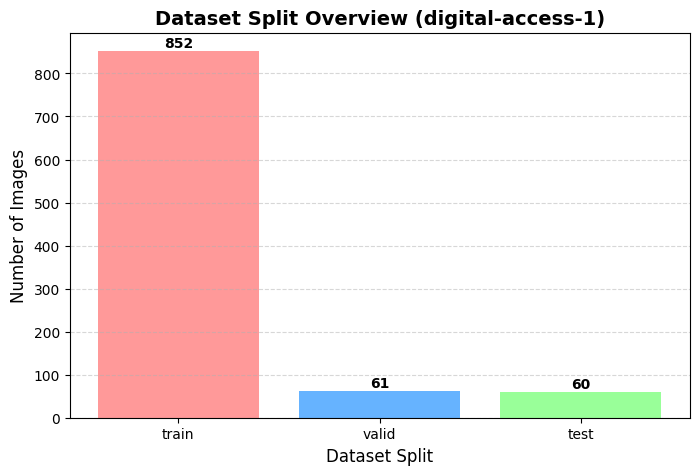

In [11]:
import os
import matplotlib.pyplot as plt

# আপনার ডেটাসেটের রুট পাথ
dataset_path = "/content/digitalaccess-1"

# ফোল্ডারগুলোর ভেতরের ইমেজ সংখ্যা গোনা
splits = ['train', 'valid', 'test']
image_counts = []

for split in splits:
    img_dir = os.path.join(dataset_path, split, "images")
    if os.path.exists(img_dir):
        count = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        image_counts.append(count)
    else:
        image_counts.append(0)

# বার চার্ট তৈরি করা
plt.figure(figsize=(8, 5))
bars = plt.bar(splits, image_counts, color=['#ff9999','#66b3ff','#99ff99'])

# বারের ওপরে সংখ্যা বসানো
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title("Dataset Split Overview (digital-access-1)", fontsize=14, fontweight='bold')
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [3]:
print(dataset.location)

/content/digitalaccess-1


In [12]:
!yolo task=detect mode=train data=/content/digitalaccess-1 model=yolov8n.pt epochs=100 imgsz=640

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/digitalaccess-1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

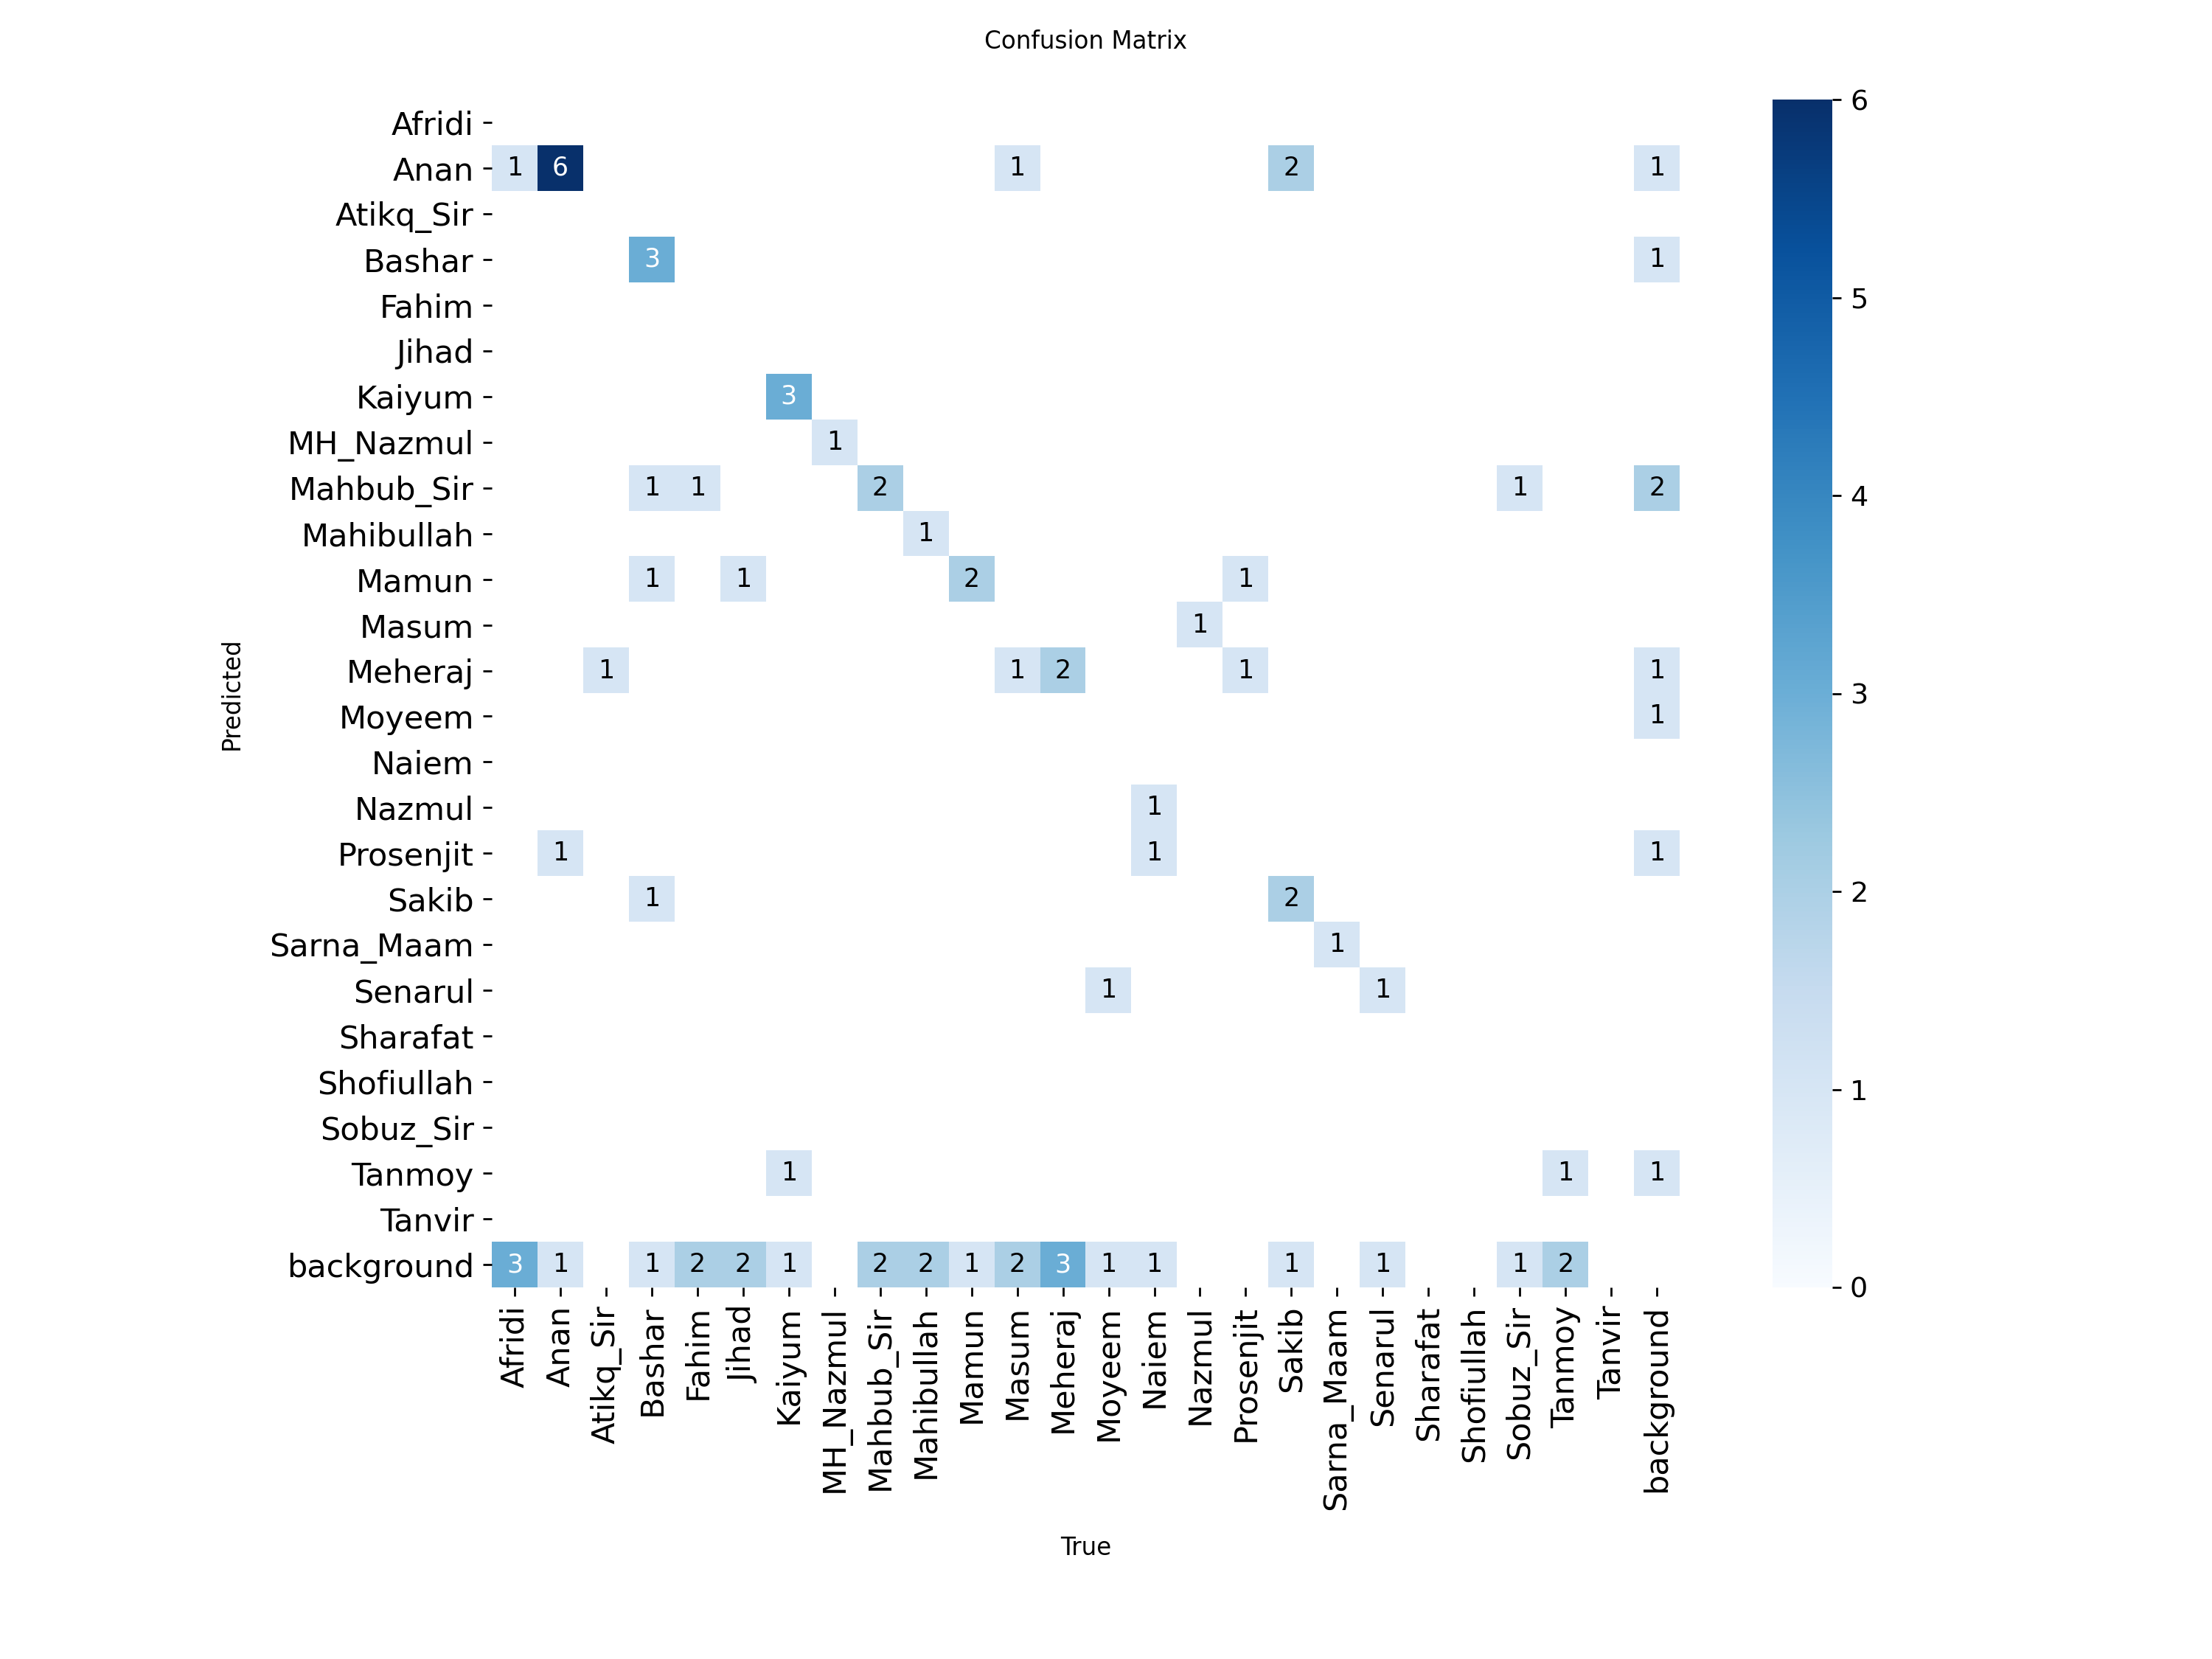

In [13]:
from IPython.display import Image
Image('/content/runs/detect/train/confusion_matrix.png', width=600)

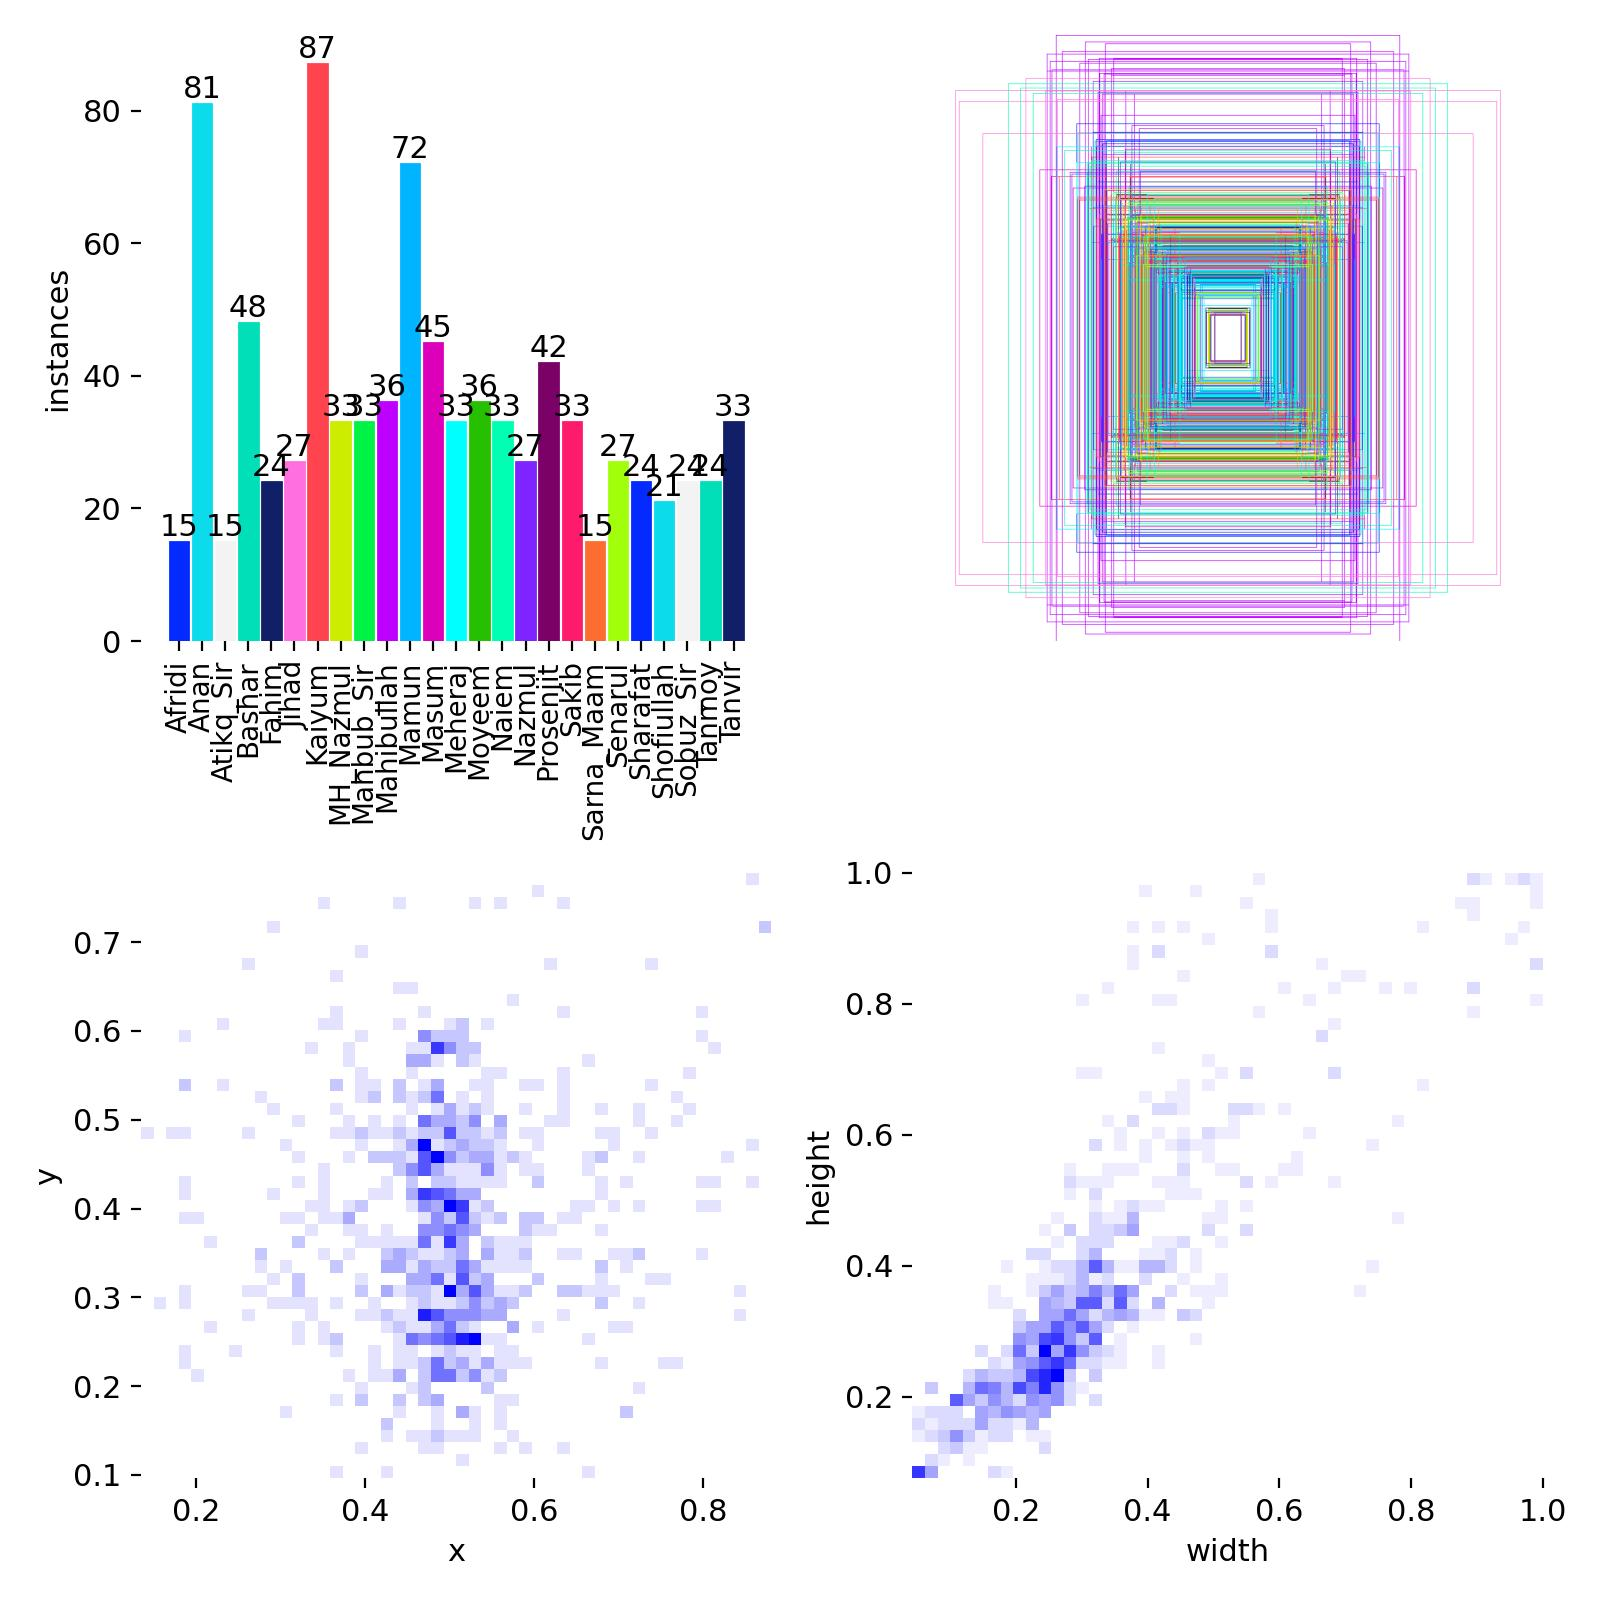

In [14]:
Image("/content/runs/detect/train/labels.jpg", width=600)

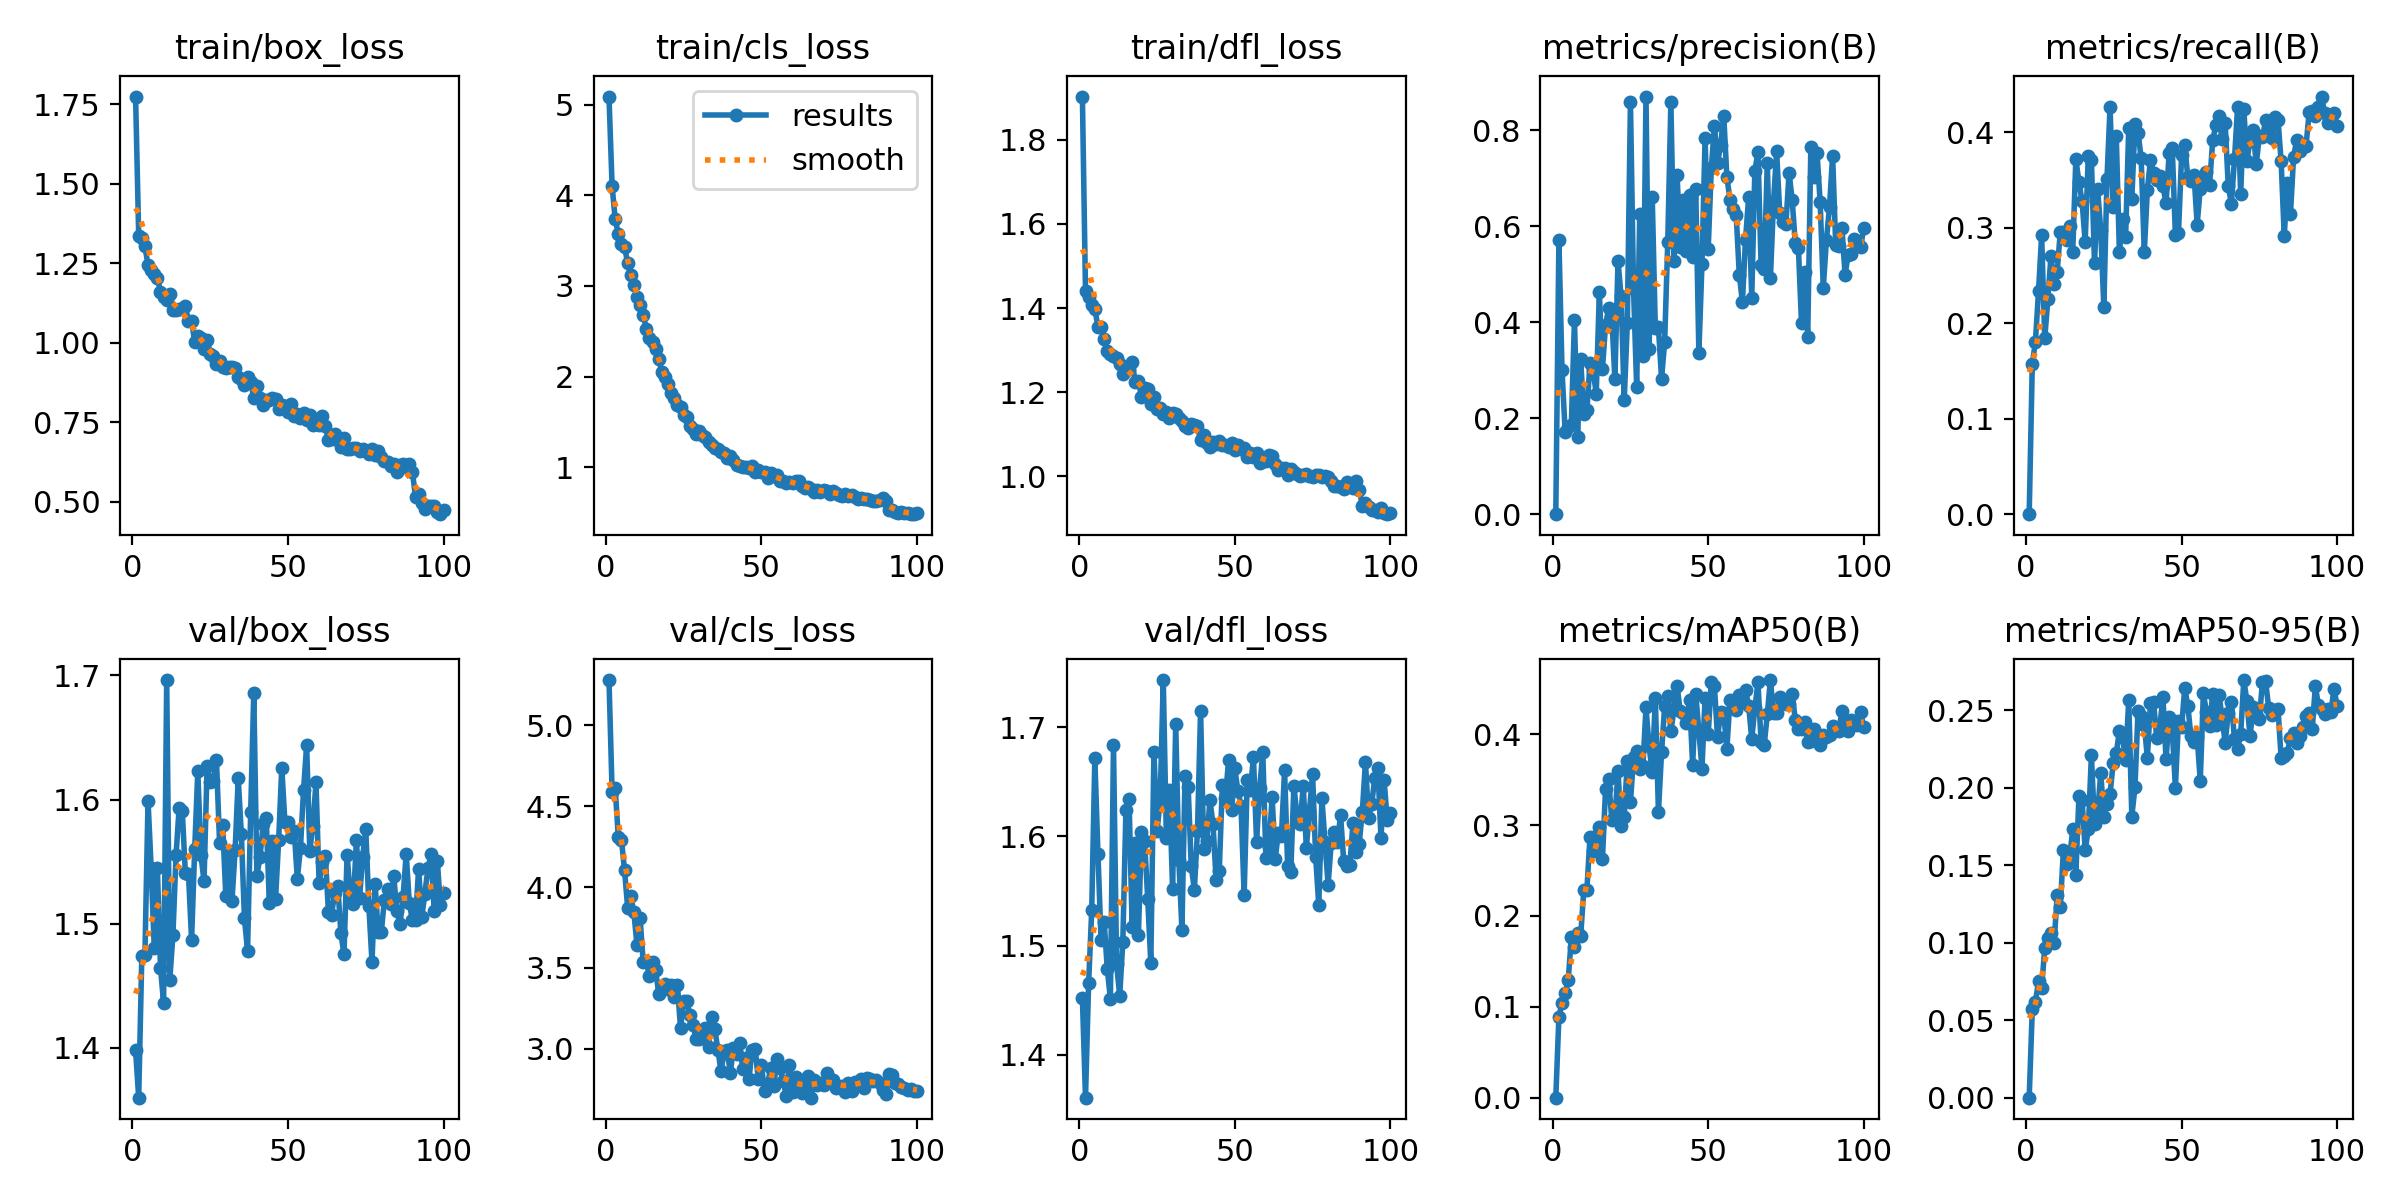

In [16]:
Image("/content/runs/detect/train/results.png", width=600)

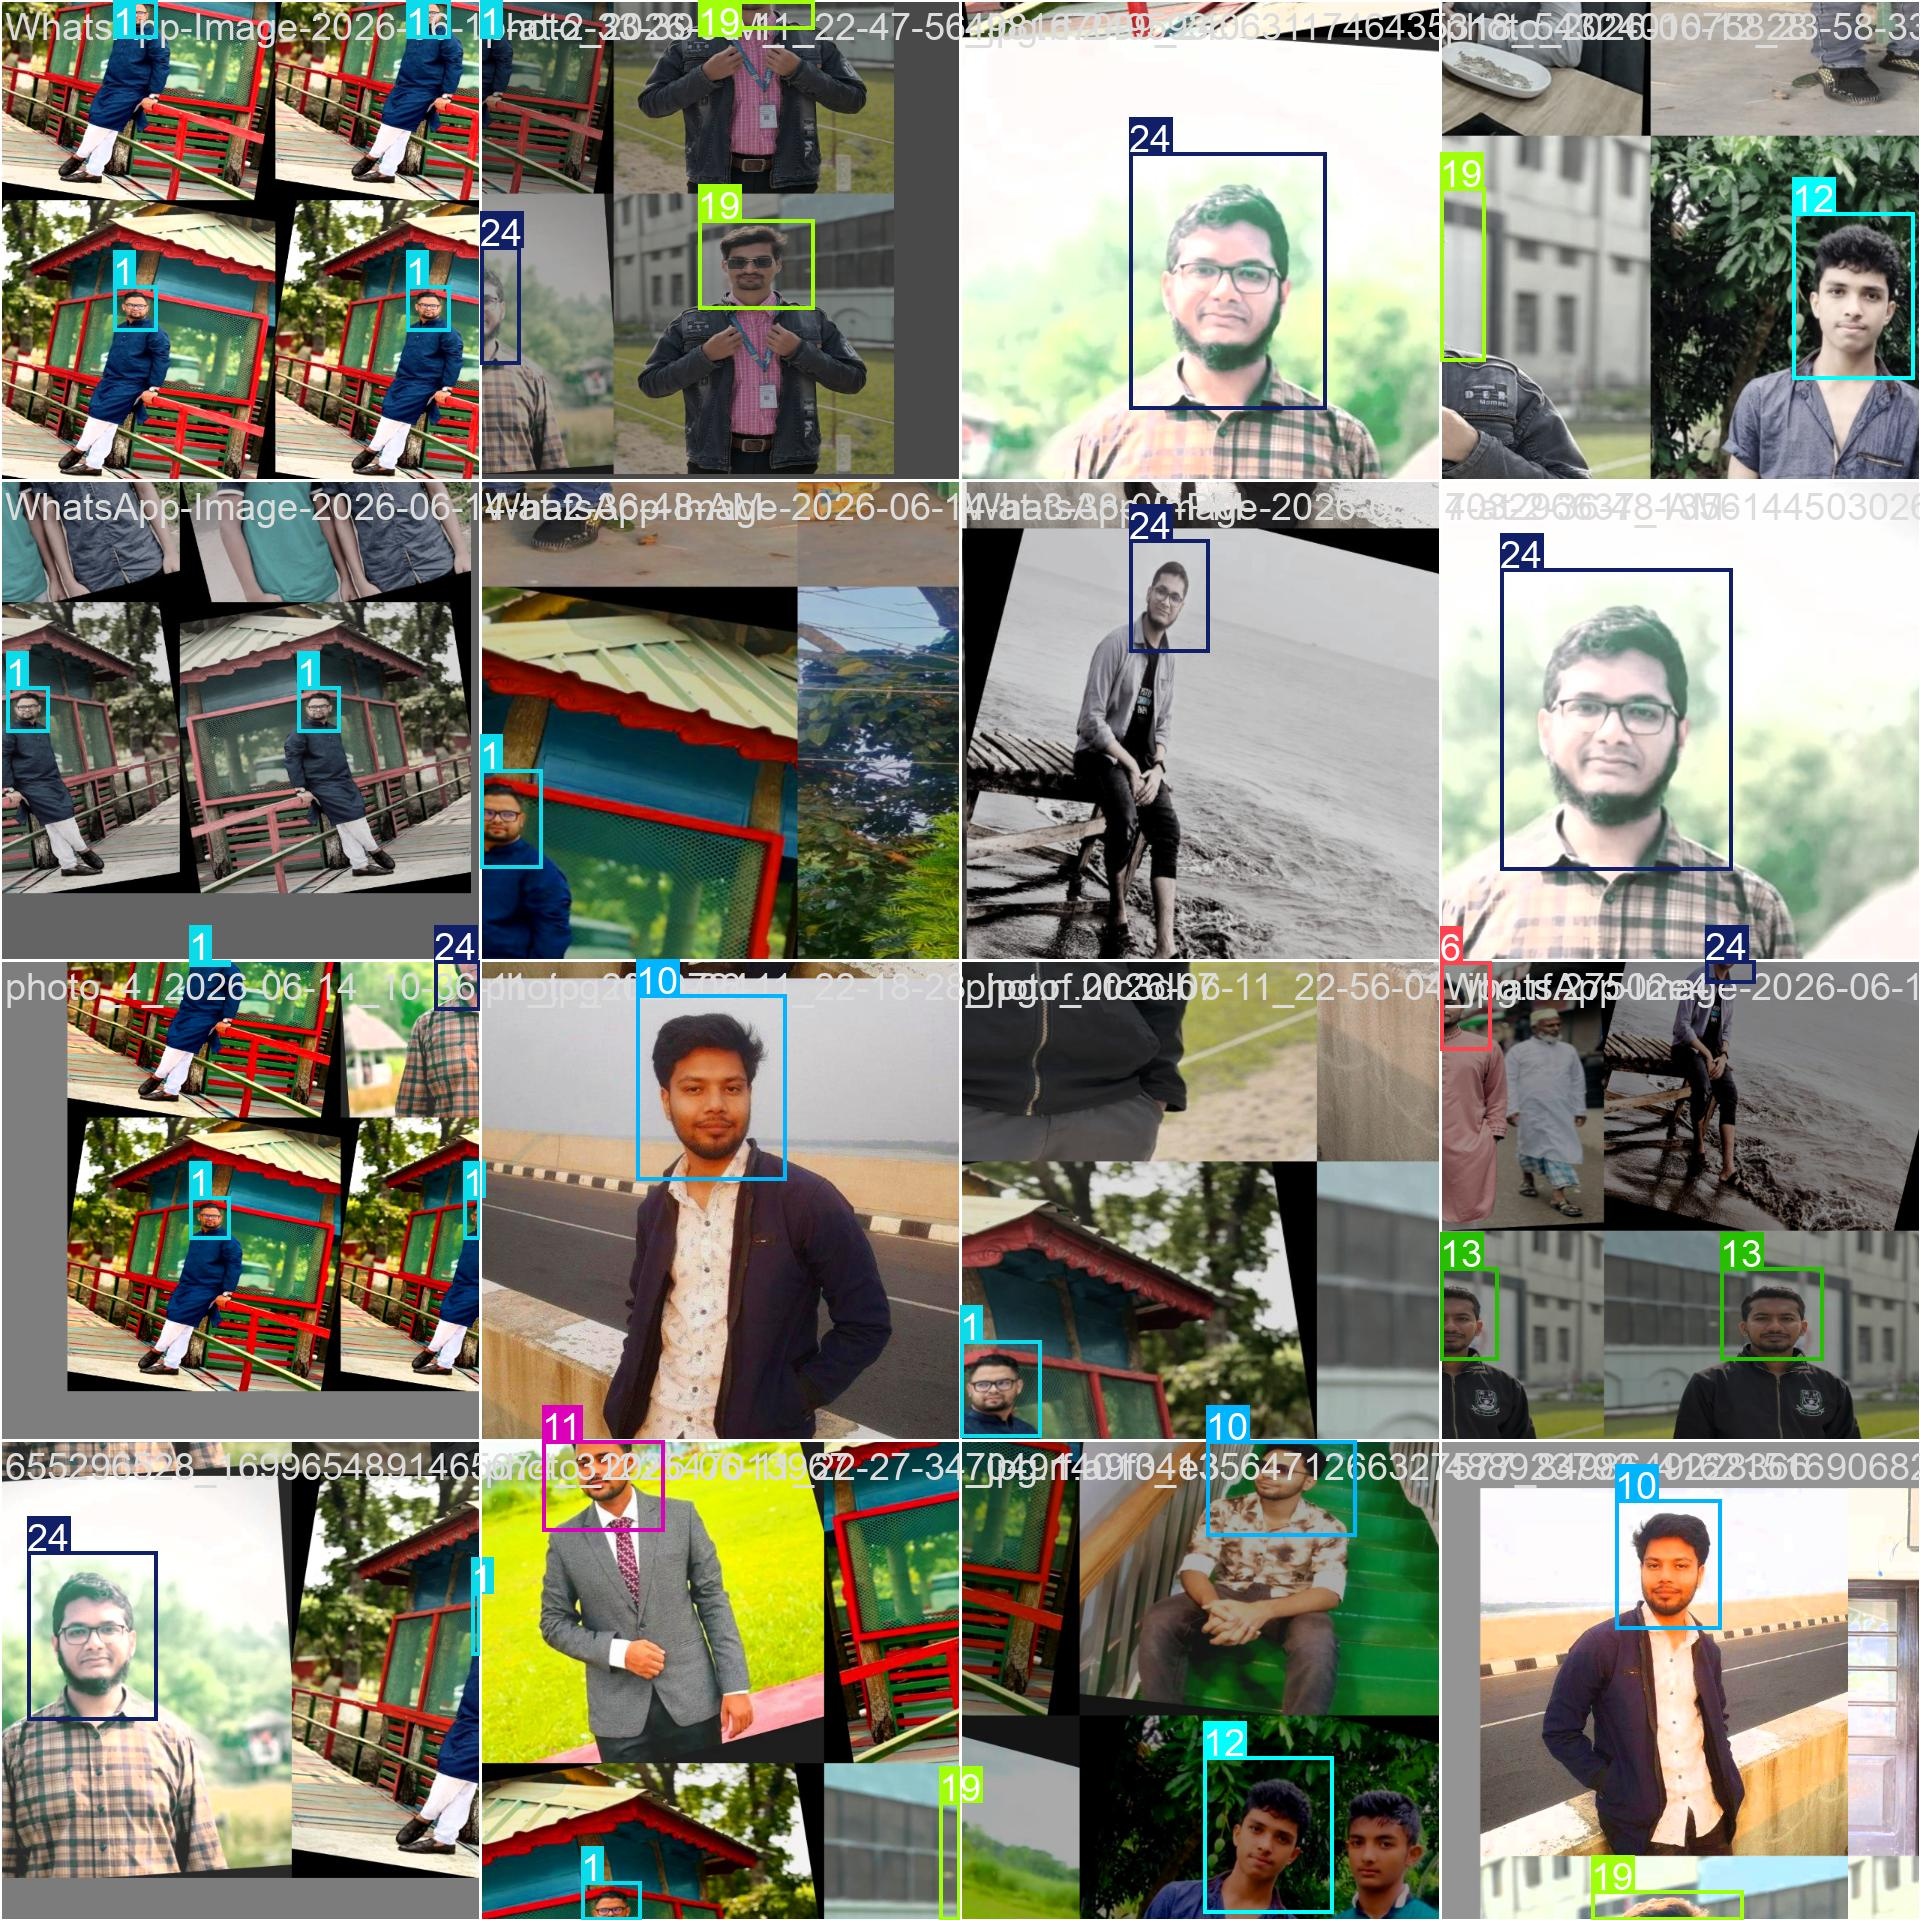

In [17]:
Image("/content/runs/detect/train/train_batch0.jpg", width=600)

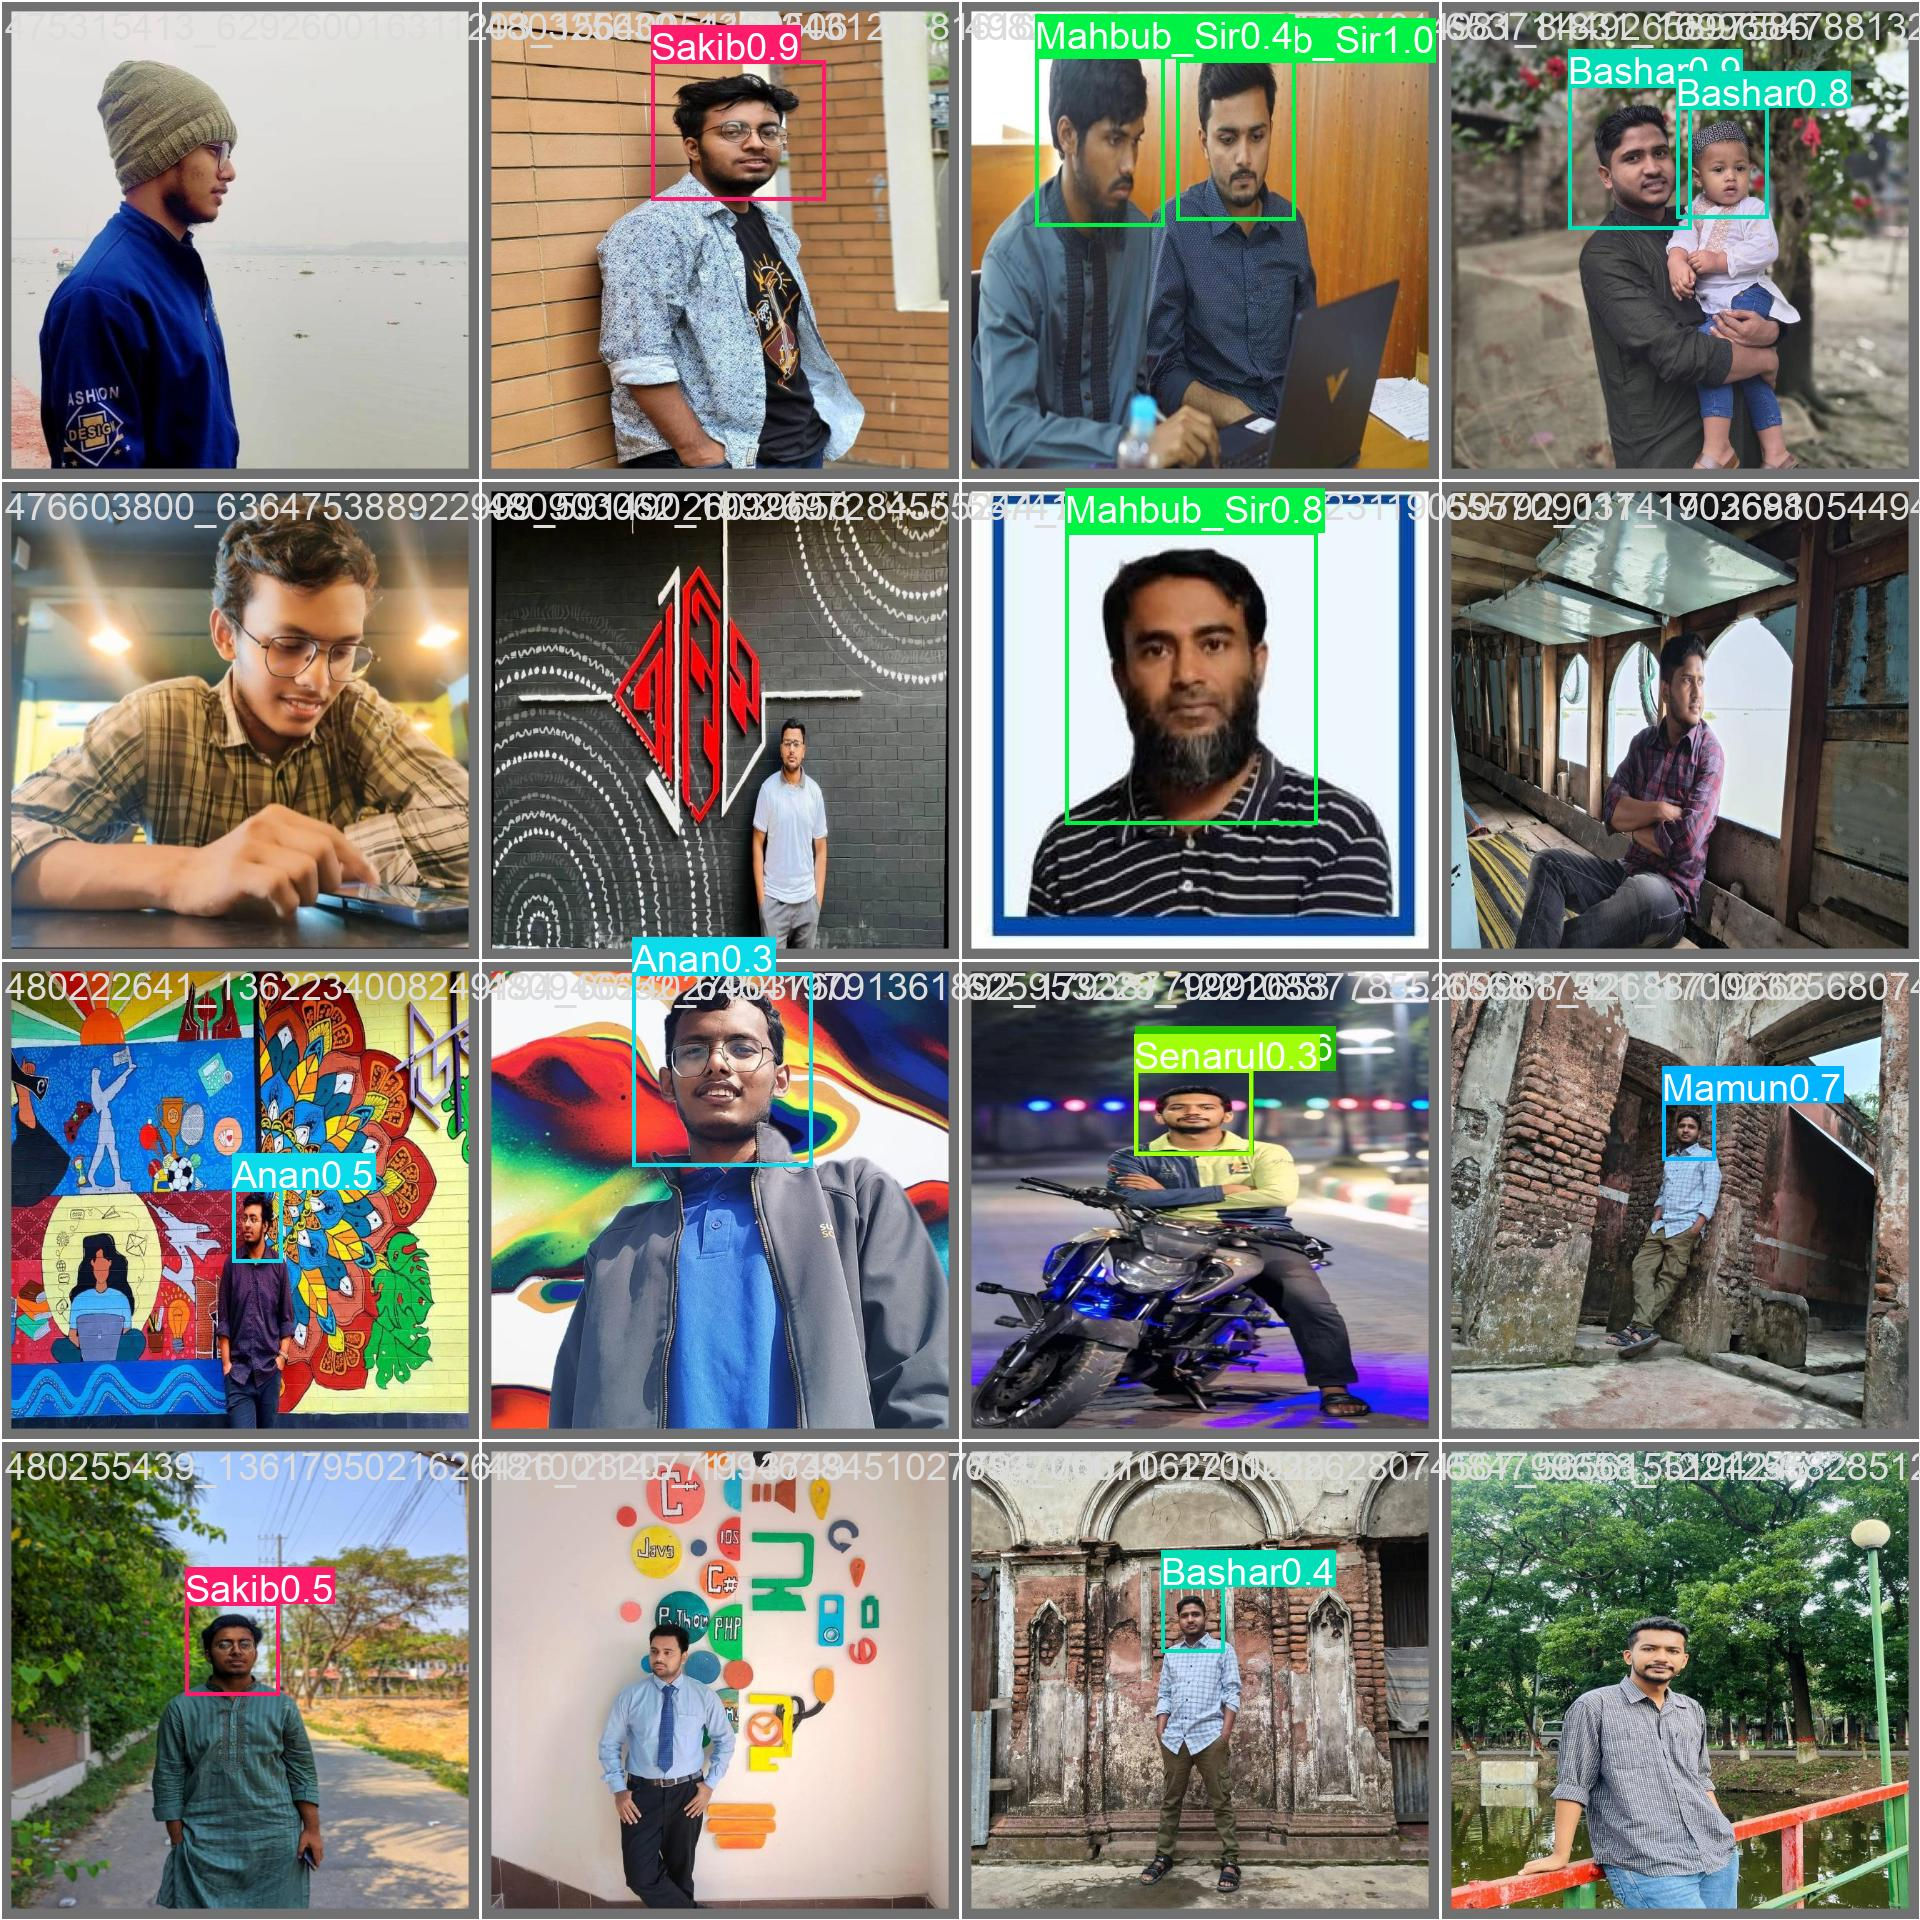

In [19]:
Image("/content/runs/detect/train/val_batch0_pred.jpg", width=600)

In [20]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1877.4±523.1 MB/s, size: 72.2 KB)
val: Scanning /content/digitalaccess-1/valid/labels.cache... 61 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 61/61 10.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2it/s 1.8s
                   all         61         72      0.492      0.425       0.46       0.27
                Afridi          4          4          1      0.579      0.816      0.694
                  Anan          8          8      0.533      0.856      0.753      0.379
             Atikq_Sir          1          1          0          0          0          0
                Bashar          7          7      0.793       0.55      0.739       0.39
                 Fahim          3          3  

In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train-3/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

In [22]:
!yolo task=detect mode=predict model= "/content/best.pt" conf=0.25 source=image2.jpg save=True!yolo task=detect mode=predict model= "/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/annan.jpg save=True

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/annan.jpg: 640x640 1 Anan, 6.8ms
Speed: 3.3ms preprocess, 6.8ms inference, 16.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [25]:
import cv2
import os
import numpy as np
import base64
from PIL import Image
import io
from google.colab.output import eval_js
from IPython.display import display, Javascript
from ultralytics import YOLO

# ১. মডেল লোড
model = YOLO("/content/runs/detect/train/weights/best.pt")

# ২. জাভাস্ক্রিপ্ট কোড: লজিটেক ক্যামেরা চালু রাখবে এবং প্রতি ফ্রেমে ডাটা পাইথনে পাঠাবে
def start_always_video():
    js = Javascript('''
        var video;
        var div;
        var stream;
        var canvas;

        async function init() {
            div = document.createElement('div');
            div.style.position = 'relative';

            video = document.createElement('video');
            video.style.display = 'block';
            video.width = 640;
            video.height = 480;

            // ওভারলে ক্যানভাস (নাম ও বক্স আঁকার জন্য)
            canvas = document.createElement('canvas');
            canvas.width = 640;
            canvas.height = 480;
            canvas.style.position = 'absolute';
            canvas.style.top = '0px';
            canvas.style.left = '0px';
            canvas.style.zIndex = '100';

            // লজিটেক এবং ব্রেভ ক্যামেরার জন্য কনস্ট্রেইন্টস
            const constraints = {
                video: { facingMode: "user", width: 640, height: 480 }
            };

            stream = await navigator.mediaDevices.getUserMedia(constraints);
            video.srcObject = stream;
            await video.play();

            document.body.appendChild(div);
            div.appendChild(video);
            div.appendChild(canvas);

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        }

        // ক্যামেরা থেকে কারেন্ট ফ্রেম নেওয়ার ফাংশন
        async function captureFrame() {
            var tempCanvas = document.createElement('canvas');
            tempCanvas.width = 640;
            tempCanvas.height = 480;
            tempCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
            return tempCanvas.toDataURL('image/jpeg', 0.85);
        }

        // রিয়েল-টাইমে বক্স এবং নাম ড্র করার ফাংশন
        function drawBoxes(predictions) {
            var ctx = canvas.getContext('2d');
            ctx.clearRect(0, 0, 640, 480); // আগের ফ্রেমের বক্স মুছে ফেলা

            predictions.forEach(pred => {
                // উজ্জ্বল লাল রঙের বক্স
                ctx.strokeStyle = '#FF0000';
                ctx.lineWidth = 4;
                ctx.strokeRect(pred.x, pred.y, pred.w, pred.h);

                // নামের ব্যাকগ্রাউন্ড পটভূমি
                ctx.fillStyle = '#FF0000';
                ctx.font = 'bold 18px Arial';
                var textWidth = ctx.measureText(pred.name).width;
                ctx.fillRect(pred.x - 2, pred.y - 28, textWidth + 60, 28);

                // সাদা রঙে নাম এবং কনফিডেন্স লেখা
                ctx.fillStyle = '#FFFFFF';
                ctx.fillText(pred.name + ' (' + pred.conf + '%)', pred.x + 5, pred.y - 8);
            });
        }

        // ভিডিও বন্ধ করার ফাংশন
        function stopVideo() {
            stream.getVideoTracks()[0].stop();
            div.remove();
        }
    ''')
    display(js)

try:
    # ৩. ভিডিও স্ট্রিমিং ও অনবরত লুপ শুরু
    start_always_video()
    eval_js('init()')
    print("🎥 লজিটেক ক্যামেরা চালু হয়েছে... (বন্ধ করতে চাইলে বাম পাশের Stop বা জেনারেট বাটনে ক্লিক করুন)")

    while True:
        # জাভাস্ক্রিপ্ট থেকে প্রতি মুহূর্তের ফ্রেম আনা
        frame_data = eval_js('captureFrame()')
        if not frame_data:
            break

        # বেস৬৪ ইমেজকে ওপেনসিভি (OpenCV) ফ্রেমে রূপান্তর
        binary = base64.b64decode(frame_data.split(',')[1])
        image = Image.open(io.BytesIO(binary))
        frame = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

        # YOLOv8 মডেল দিয়ে ডিটেকশন (কনফিডেন্স ০.২৫ রাখা হয়েছে)
        results = model.predict(source=frame, conf=0.5, verbose=False)

        # ডিটেকশন রেজাল্ট ফিল্টার করা
        predictions = []
        for box in results[0].boxes:
            coords = box.xyxy[0].tolist()
            x = int(coords[0])
            y = int(coords[1])
            w = int(coords[2] - coords[0])
            h = int(coords[3] - coords[1])

            conf = int(box.conf[0].item() * 100)
            cls_id = int(box.cls[0].item())
            name = model.names[cls_id]

            predictions.append({
                'x': x, 'y': y, 'w': w, 'h': h,
                'name': name, 'conf': conf
            })

        # জাভাস্ক্রিপ্ট ক্যানভাসে ডাটা পাঠানো যাতে লাইভ ভিডিওর ওপর নাম ভেসে ওঠে
        eval_js(f'drawBoxes({predictions})')

except KeyboardInterrupt:
    eval_js('stopVideo()')
    print("\n🛑 ভিডিও ক্যাপচার বন্ধ করা হয়েছে।")
except Exception as e:
    print(f"ভুল হয়েছে: {e}")
    try:
        eval_js('stopVideo()')
    except:
        pass

<IPython.core.display.Javascript object>

🎥 লজিটেক ক্যামেরা চালু হয়েছে... (বন্ধ করতে চাইলে বাম পাশের Stop বা জেনারেট বাটনে ক্লিক করুন)

🛑 ভিডিও ক্যাপচার বন্ধ করা হয়েছে।
